In [6]:
from geotracks import SEVIRIDataBuffer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

# SEVIRI data field
- already been regridded onto regular grid

In [ ]:
# open seviri data field
data_field=xr.open_dataset('/disk1/Users/act122/shiptracks/test_field.nc').cdnc.load()/1e6

# open example ship track
track=xr.open_dataset('/disk1/Users/act122/shiptracks/tracklocs/SEVIRI/namibia_tracklocs_2018003.nc').isel(time=15,id=9)
track = np.stack([track['lon'].values, track['lat'].values, track['alt'].values], axis=-1)

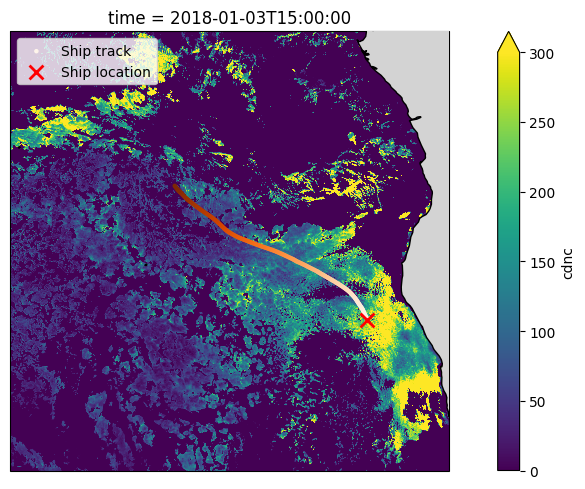

In [ ]:
# plot
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
data_field.plot(x='Longitude', y='Latitude', cmap='viridis', vmax=300,transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=10,facecolor='lightgray',edgecolor='black')
ax.scatter(track[:, 0], track[:, 1], c=np.linspace(0, 1, len(track)), cmap='Oranges', s=5, transform=ccrs.PlateCarree(),label='Ship track')
ax.scatter(track[0, 0], track[0, 1], c='red', s=100,lw=2,marker='x', transform=ccrs.PlateCarree(),label='Ship location')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Regrid around the track

In [11]:
buf = SEVIRIDataBuffer(track)
df = buf.extract(data_field)
df

,lon,lat,track_index,distance_from_track,data,time_along_track
0,8.51,-20.14,0,105.579225,232.078506,0.000000
1,8.51,-20.13,0,105.084433,231.546387,0.000000
2,8.52,-20.13,0,104.147023,239.838806,0.000000
3,8.53,-20.13,0,103.211712,249.405167,0.000000
4,8.50,-20.12,0,105.542978,226.559158,0.000000
...,...,...,...,...,...,...
164721,-2.94,-10.01,2149,-107.849452,101.962570,35.816667
164722,-2.93,-10.01,2149,-108.747749,105.763443,35.816667
164723,-2.92,-10.01,2148,-109.646290,101.554474,35.800000
164724,-2.94,-10.00,2149,-108.493930,58.160507,35.816667


# put into 2D plot (depending on desired resolution)

In [14]:
DIST_BINS = np.arange(-100, 101, 1)
TIME_BINS = np.arange(0, 37, 0.25)


df["dist_binned"] = pd.cut(
    df["distance_from_track"], DIST_BINS, labels=DIST_BINS[:-1]
)
df["time_binned"] = pd.cut(df["time_along_track"], TIME_BINS, labels=TIME_BINS[:-1])

df2d = pd.pivot_table(
    df,
    index="dist_binned",
    columns="time_binned",
    values="data",
    aggfunc="mean",
    dropna=False,
)
ds2d = xr.DataArray(df2d).isel(dist_binned=slice(1, 201))

ds2d

<xarray.DataArray (dist_binned: 200, time_binned: 147)>
array([[329.26035, 312.09393, 273.44455, ...,       nan,       nan,
              nan],
       [338.29733, 305.60928, 291.36298, ...,       nan,       nan,
              nan],
       [336.96393, 309.4846 , 312.05014, ...,       nan,       nan,
              nan],
       ...,
       [288.61542, 304.71146, 238.95126, ...,       nan,       nan,
              nan],
       [286.14178, 308.7813 , 238.93988, ...,       nan,       nan,
              nan],
       [284.30212, 306.6594 , 231.91022, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * dist_binned  (dist_binned) int64 -100 -99 -98 -97 -96 -95 ... 95 96 97 98 99
  * time_binned  (time_binned) float64 0.0 0.25 0.5 0.75 ... 36.0 36.25 36.5

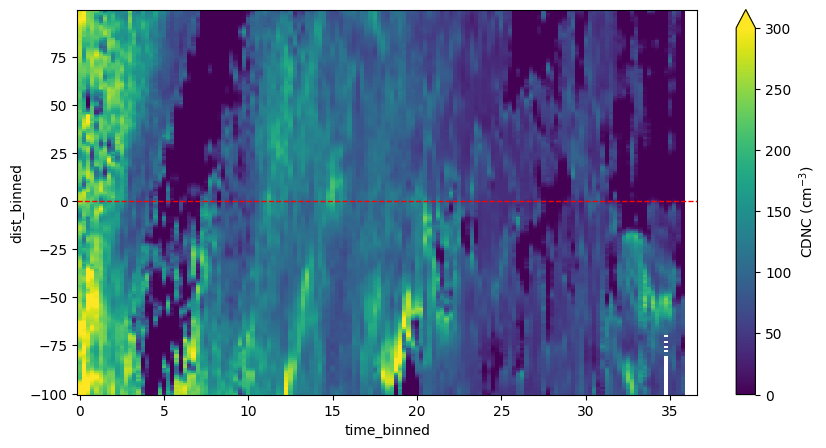

In [15]:
fig,ax=plt.subplots(figsize=(10, 5))
ds2d.plot(vmax=300, ax=ax, cmap='viridis', cbar_kwargs={'label': 'CDNC (cm$^{-3}$)'})
ax.axhline(0, color='red', lw=1, ls='--')